<a href="https://colab.research.google.com/github/vidyasreedharan2003-a11y/ML-PROJECT/blob/main/vidya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
df=pd.read_csv('/content/the_loan.csv')

In [128]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [129]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [130]:
df.shape

(614, 13)

In [131]:
df.size

7982

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [133]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [134]:
df=df.drop(columns=['Loan_ID','Gender'])

In [135]:
df=df.dropna(subset=['Married'])

df.isnull().sum()

,0
Married,0
Dependents,12
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14
Credit_History,50
Property_Area,0


In [136]:
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [137]:
cols=['Credit_History','LoanAmount','Loan_Amount_Term']
df[cols]=df[cols].fillna(df[cols].mean())

In [138]:
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])

In [139]:
df.isnull().sum()

,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area,0


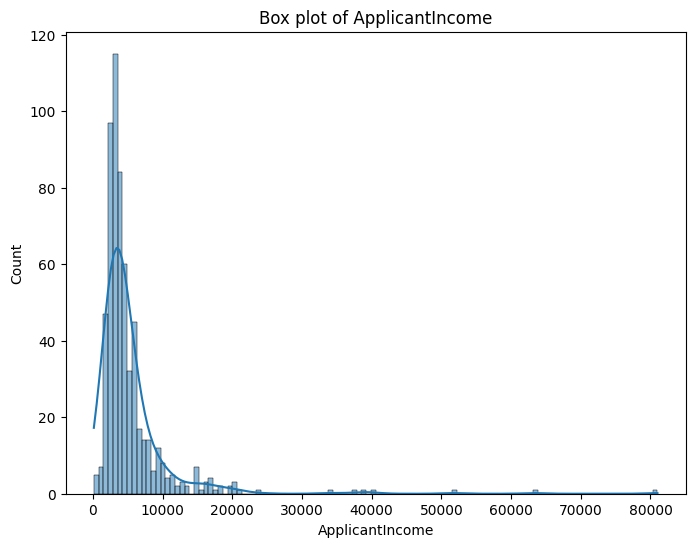

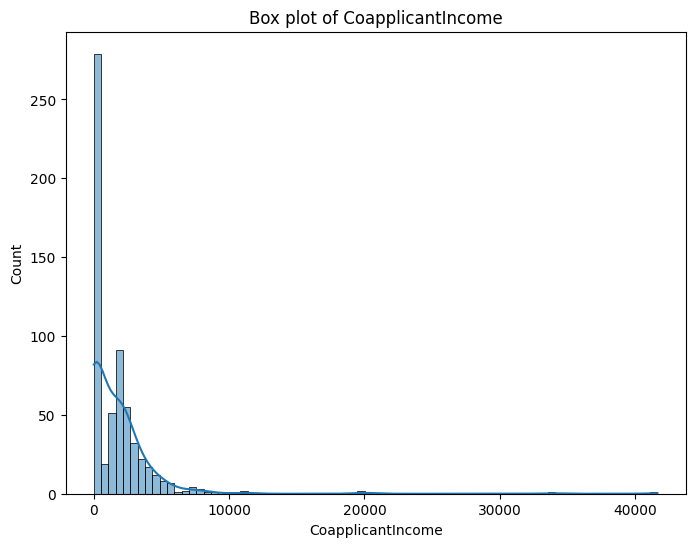

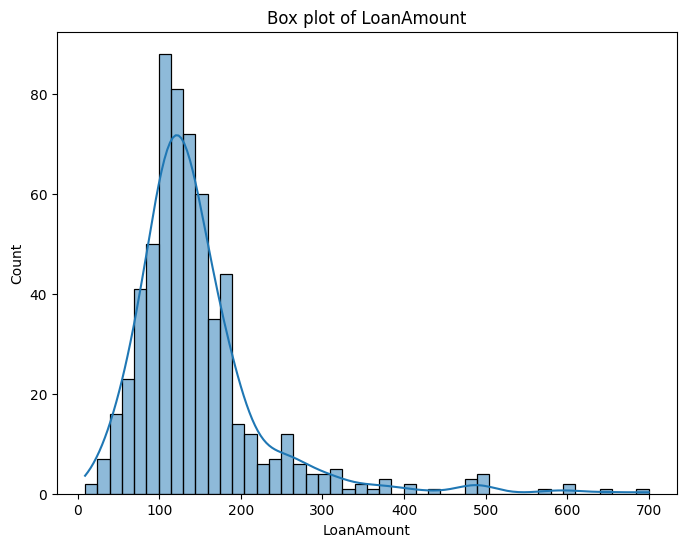

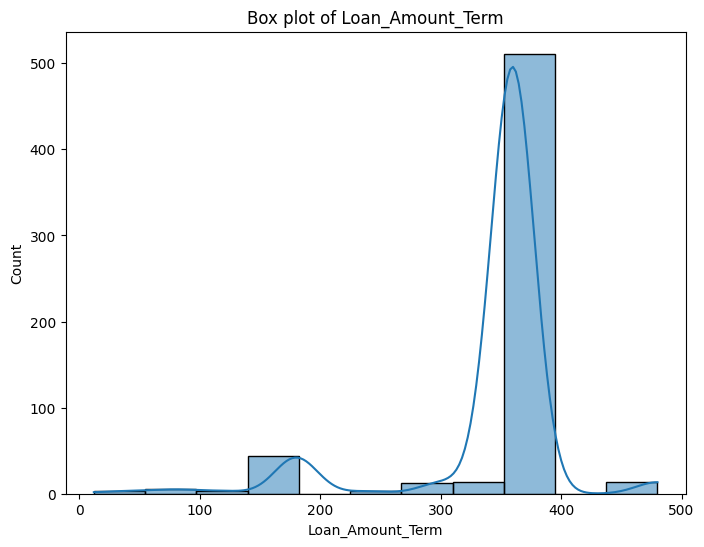

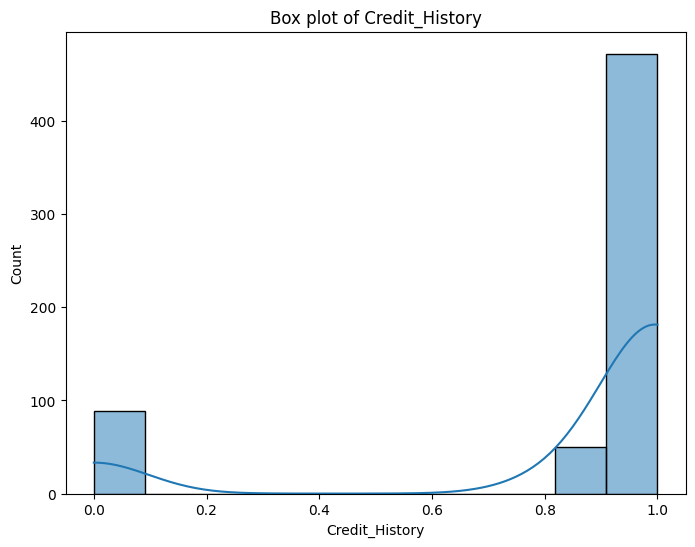

In [140]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.histplot(df[col],kde=True)
  plt.title(f"Box plot of {col}")
  plt.show()

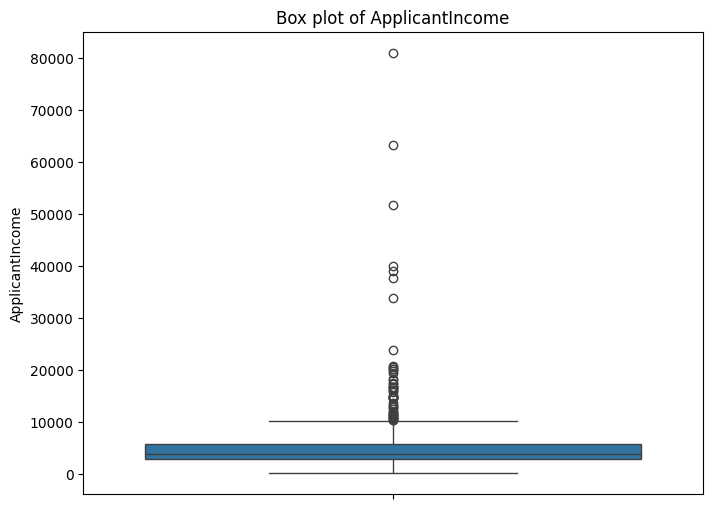

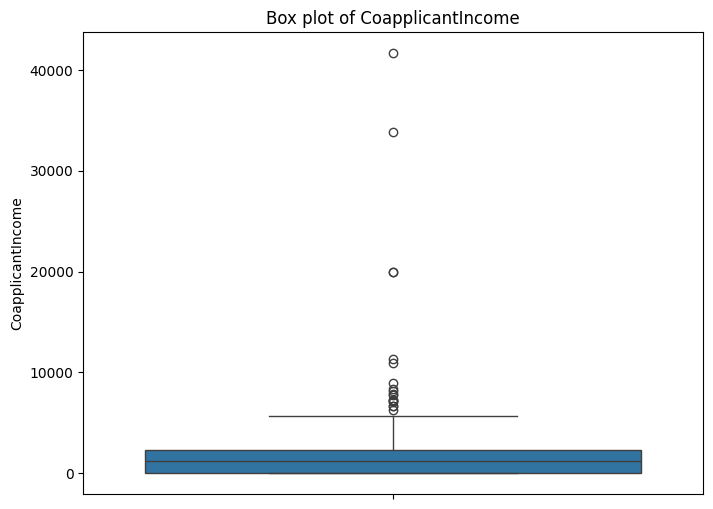

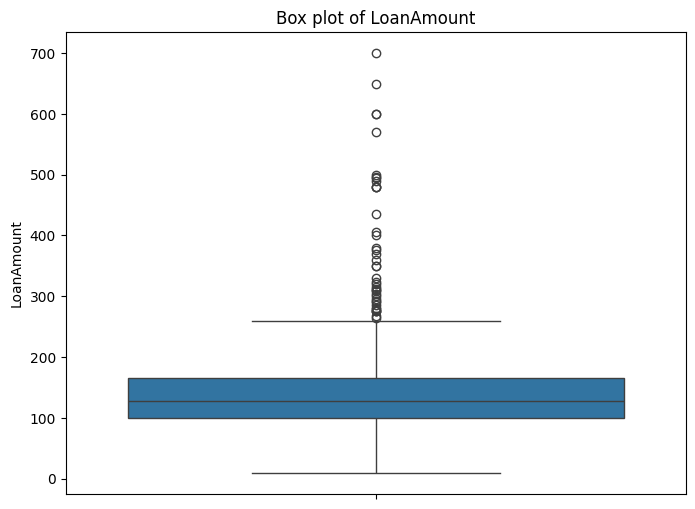

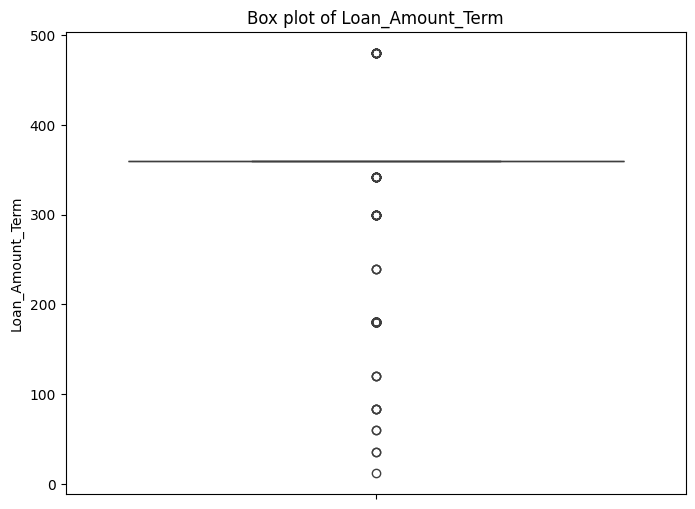

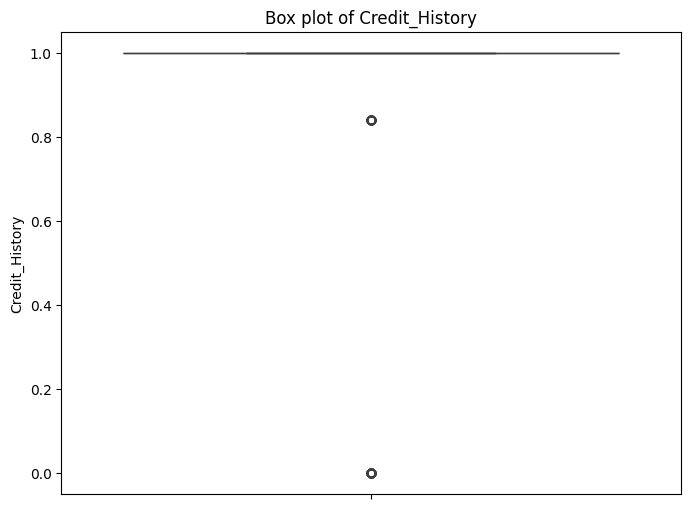

In [141]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=df[col])
  plt.title(f"Box plot of {col}")
  plt.show()

In [142]:
from scipy.stats.mstats import winsorize
for col in ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']:
  df[col] = winsorize(df[col], limits=(0.1, 0.1))

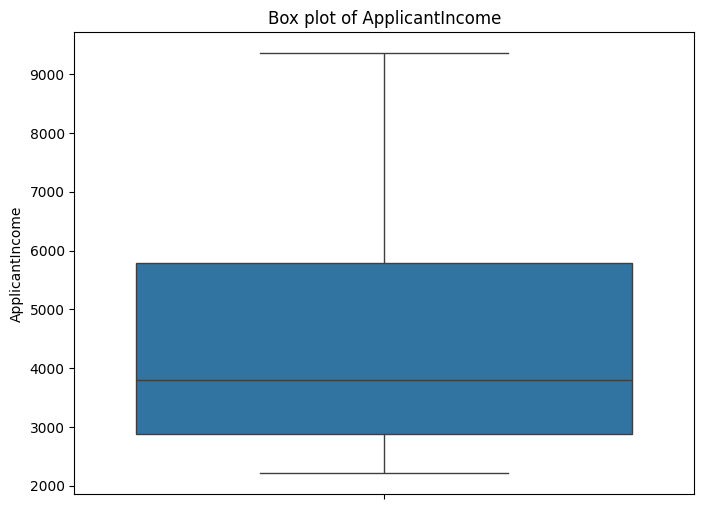

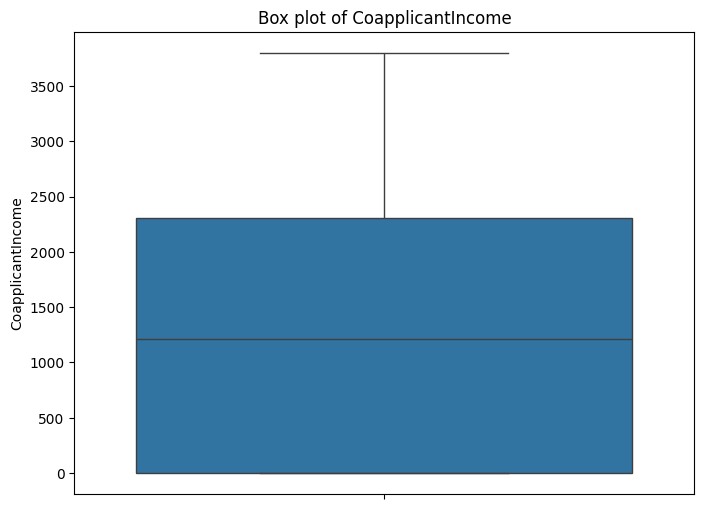

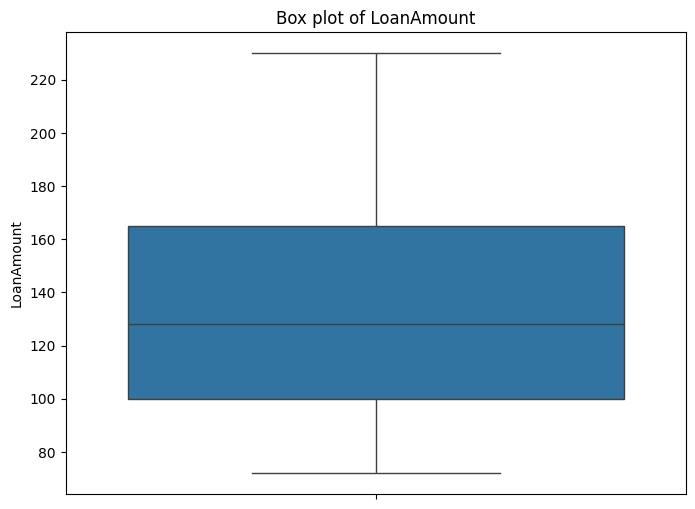

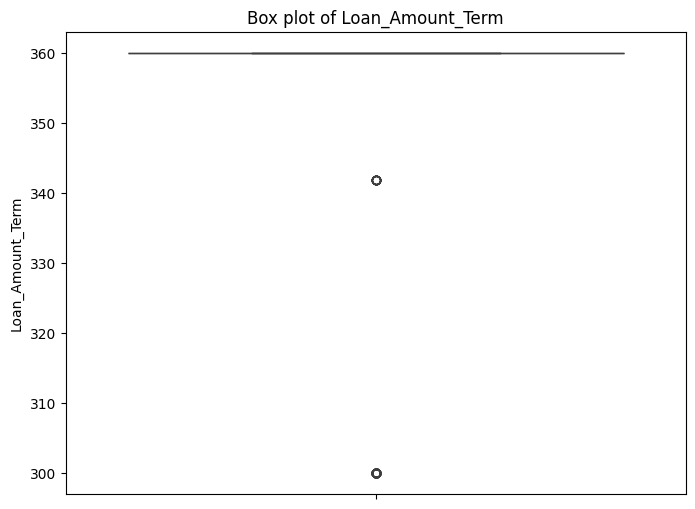

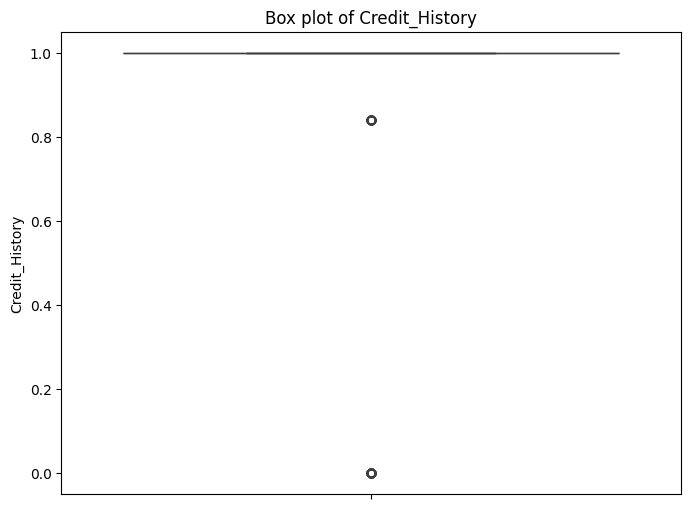

In [143]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=df[col])
  plt.title(f"Box plot of {col}")
  plt.show()

In [210]:
from scipy.stats import skew
cat_value=df.select_dtypes(include=["object"]).columns
num_value=df.select_dtypes(include=["int64","float64"]).columns

skew_value=df[num_value].skew()

skew_value

,0
Married,-0.636955
Dependents,1.008242
Education,1.360037
Self_Employed,2.151498
ApplicantIncome,1.001000
CoapplicantIncome,0.515505
LoanAmount,0.571676
Loan_Amount_Term,-2.303549
Credit_History,-1.954970
Loan_Status,-0.802299


In [145]:
df['Married'].unique()

array([0, 1])

In [146]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Married']=le.fit_transform(df['Married'])
df.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,Graduate,No,5849,0.0,146.369492,360.0,1.0,Urban,Y
1,1,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,1,0,Graduate,Yes,3000,0.0,72.000000,360.0,1.0,Urban,Y
3,1,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,0,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


In [147]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df['Education']=oe.fit_transform(df[['Education']])

In [148]:
df['Self_Employed'].unique()

array(['No', 'Yes'], dtype=object)

In [149]:
df['Self_Employed']=le.fit_transform(df['Self_Employed'])
df.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0.0,0,5849,0.0,146.369492,360.0,1.0,Urban,Y
1,1,1,0.0,0,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,1,0,0.0,1,3000,0.0,72.000000,360.0,1.0,Urban,Y
3,1,0,1.0,0,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,0,0,0.0,0,6000,0.0,141.000000,360.0,1.0,Urban,Y


In [150]:
df['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [151]:
df=pd.get_dummies(df,columns=["Property_Area"],prefix="Property_Area",drop_first=True)


In [152]:
bol_cols=df.select_dtypes(include='bool').columns
df[bol_cols]=df[bol_cols].astype(int)

In [153]:
df.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0.0,0,5849,0.0,146.369492,360.0,1.0,Y,0,1
1,1,1,0.0,0,4583,1508.0,128.000000,360.0,1.0,N,0,0
2,1,0,0.0,1,3000,0.0,72.000000,360.0,1.0,Y,0,1
3,1,0,1.0,0,2583,2358.0,120.000000,360.0,1.0,Y,0,1
4,0,0,0.0,0,6000,0.0,141.000000,360.0,1.0,Y,0,1


In [154]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Loan_Status']=le.fit_transform(df['Loan_Status'])
df.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0.0,0,5849,0.0,146.369492,360.0,1.0,1,0,1
1,1,1,0.0,0,4583,1508.0,128.000000,360.0,1.0,0,0,0
2,1,0,0.0,1,3000,0.0,72.000000,360.0,1.0,1,0,1
3,1,0,1.0,0,2583,2358.0,120.000000,360.0,1.0,1,0,1
4,0,0,0.0,0,6000,0.0,141.000000,360.0,1.0,1,0,1


In [155]:
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 611 entries, 0 to 613
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Married                  611 non-null    int64  
 1   Dependents               611 non-null    int64  
 2   Education                611 non-null    float64
 3   Self_Employed            611 non-null    int64  
 4   ApplicantIncome          611 non-null    int64  
 5   CoapplicantIncome        611 non-null    float64
 6   LoanAmount               611 non-null    float64
 7   Loan_Amount_Term         611 non-null    float64
 8   Credit_History           611 non-null    float64
 9   Loan_Status              611 non-null    int64  
 10  Property_Area_Semiurban  611 non-null    int64  
 11  Property_Area_Urban      611 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 62.1 KB


In [157]:
y=df['Loan_Status']
x=df.drop(columns=['Loan_Status'])

In [158]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [159]:
from scipy.stats import skew
cat_value=df.select_dtypes(include=["object"]).columns
num_value=df.select_dtypes(include=["int64","float64"]).columns

skew_value=df[num_value].skew()

skew_value

,0
Married,-0.636955
Dependents,1.008242
Education,1.360037
Self_Employed,2.151498
ApplicantIncome,1.001000
CoapplicantIncome,0.515505
LoanAmount,0.571676
Loan_Amount_Term,-2.303549
Credit_History,-1.954970
Loan_Status,-0.802299


In [185]:
from sklearn.preprocessing import StandardScaler
se=StandardScaler()
x_train = se.fit_transform(x_train)
# Transform the test features using the scaler fitted on training data
x_test = se.transform(x_test)

In [186]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()
lr_model.fit(x_train,y_train)

LogisticRegression()

In [187]:
y_predict=lr_model.predict(x_test)
y_predict

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [188]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score

In [189]:
confusion_matrix(y_test,y_predict)

array([[ 19,  27],
       [  4, 103]])

In [190]:
accuracy=accuracy_score(y_test,y_predict)

In [191]:
accuracy

0.7973856209150327

In [192]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=10,random_state=42,min_samples_leaf=10)
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.7581699346405228


array([[20, 26],
       [11, 96]])

In [193]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=20,
                                max_depth=10,
                                min_samples_split=3)
rf_model.fit(x_train,y_train)
y_pred=rf_model.predict(x_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.7908496732026143


array([[ 20,  26],
       [  6, 101]])

In [194]:
from sklearn.neighbors import KNeighborsClassifier

metric_k={}

neighbors=np.arange(3,20)
for k in neighbors:
  knn_model=KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2)  #p=1 implies euclian
  knn_model.fit(x_train,y_train)
  y_predict=knn_model.predict(x_test)
  acc=accuracy_score(y_test,y_predict)
  metric_k[k]=acc
metric_k


{np.int64(3): 0.738562091503268,
 np.int64(4): 0.7647058823529411,
 np.int64(5): 0.7973856209150327,
 np.int64(6): 0.7777777777777778,
 np.int64(7): 0.7973856209150327,
 np.int64(8): 0.7843137254901961,
 np.int64(9): 0.7843137254901961,
 np.int64(10): 0.7908496732026143,
 np.int64(11): 0.803921568627451,
 np.int64(12): 0.7973856209150327,
 np.int64(13): 0.8104575163398693,
 np.int64(14): 0.8169934640522876,
 np.int64(15): 0.8104575163398693,
 np.int64(16): 0.803921568627451,
 np.int64(17): 0.7973856209150327,
 np.int64(18): 0.803921568627451,
 np.int64(19): 0.7908496732026143}

In [195]:
knn_model=KNeighborsClassifier(n_neighbors=10,)
knn_model.fit(x_train,y_train)
y_predict=knn_model.predict(x_test)
acc=accuracy_score(y_test,y_predict)
acc

0.7908496732026143

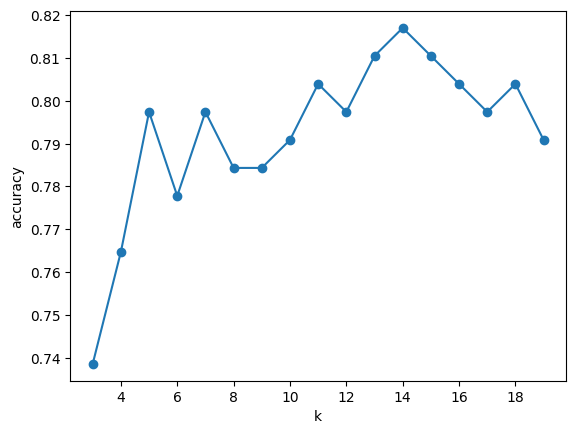

In [207]:
plt.plot(metric_k.keys(),metric_k.values(),marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()

In [196]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train,y_train)
y_pred=nb_model.predict(x_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.8104575163398693


array([[ 19,  27],
       [  2, 105]])

In [204]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a RandomForestClassifier instance
rf_model_grid = RandomForestClassifier(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=rf_model_grid, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the GridSearchCV object to the training data
grid_search.fit(x_train, y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Evaluate the best model on the test set
best_rf_model = grid_search.best_estimator_
y_pred_grid = best_rf_model.predict(x_test)
print("Test accuracy with best model: ", accuracy_score(y_test, y_pred_grid))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found:  {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy:  0.8078356426182512
Test accuracy with best model:  0.803921568627451


In [206]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define the parameter grid to search for GaussianNB
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100) # Search a wide range of values for var_smoothing
}

# Create a GaussianNB instance
nb_model_grid = GaussianNB()

# Create the GridSearchCV object
grid_search_nb = GridSearchCV(estimator=nb_model_grid, param_grid=param_grid_nb, cv=5, n_jobs=-1, verbose=2)

# Fit the GridSearchCV object to the training data
grid_search_nb.fit(x_train, y_train)

# Print the best parameters and the best score
print("Best parameters found for GaussianNB: ", grid_search_nb.best_params_)
print("Best cross-validation accuracy for GaussianNB: ", grid_search_nb.best_score_)

# Evaluate the best model on the test set
best_nb_model = grid_search_nb.best_estimator_
y_pred_nb = best_nb_model.predict(x_test)
print("Test accuracy with best GaussianNB model: ", accuracy_score(y_test, y_pred_nb))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found for GaussianNB:  {'var_smoothing': np.float64(1.0)}
Best cross-validation accuracy for GaussianNB:  0.8078356426182512
Test accuracy with best GaussianNB model:  0.8104575163398693


In [197]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [198]:
model=Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(10,activation='relu'))
model.add(Dense(2,activation='softmax'))

In [199]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))

loss, accuracy=model.evaluate(x_test,y_test)

print("Test accuracy",accuracy)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6569 - loss: 0.6689 - val_accuracy: 0.6601 - val_loss: 0.6862
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6637 - loss: 0.6452 - val_accuracy: 0.6863 - val_loss: 0.6548
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7126 - loss: 0.5730 - val_accuracy: 0.7255 - val_loss: 0.6275
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7547 - loss: 0.5506 - val_accuracy: 0.7386 - val_loss: 0.6088
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7898 - loss: 0.5233 - val_accuracy: 0.7647 - val_loss: 0.5925
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8076 - loss: 0.5000 - val_accuracy: 0.7712 - val_loss: 0.5802
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7919 - loss: 0.5083 - val_accuracy: 0.7712 - val_loss: 0.5679
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7879 - loss: 0.5142 - val_accuracy: 0.7843 - v

In [200]:
predictions=model.predict(x_test)
predictions_class=np.argmax(predictions,axis=1)
predictions_class

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [202]:
new_data=np.array([[5.1,3.5,1.4,0.2,1.55,0.8,1.2,2.8,3.5,1.77,3],[3.25,6.0,2.7,4.2,1.3,2,5.1,3,2.88,1,1.28]])
new_data=se.transform(new_data)
predictions=model.predict(new_data)
predictions_class=np.argmax(predictions,axis=1)
predictions_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([1, 1])

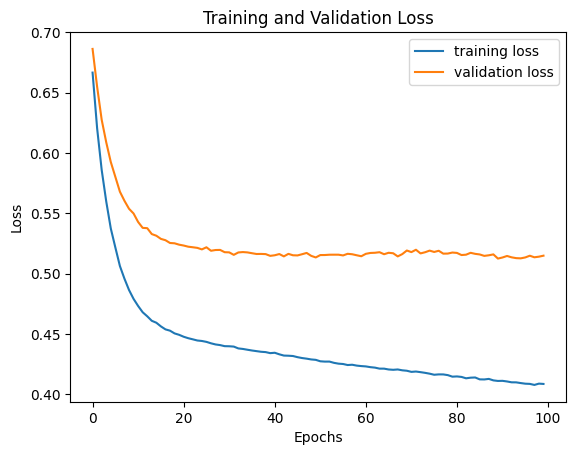

In [208]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

In [209]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428 (1.68 KB)

 Trainable params: 142 (568.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 286 (1.12 KB)